In [10]:
''' Make burn probability figures for the paper '''
import os
import geopandas as gpd
import pandas as pd
import numpy as np
import rasterio
import xarray as xr
import zarr
import argparse
import shapely

import cartopy.crs as ccrs
from rasterio.plot import show
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
import matplotlib.cm as cm
import matplotlib.axes as maxes
from mpl_toolkits.axes_grid1 import make_axes_locatable
from pyproj import Transformer

def parse_args(args=None):
    def str2float(v):
        return float(v)
    
    parser = argparse.ArgumentParser(
        description="Postprocess simulation results",
        formatter_class=argparse.RawTextHelpFormatter
    )
    parser.add_argument(
        '--fire-id',
        dest='fid',
        required=True,
        help='Fire ID'
    )
    parser.add_argument(
        '--input',
        dest='zarr_path',
        required=False,
        default=None,
        help='Path to zarr file.'
    )
    parser.add_argument(
        '--firecube-path',
        required=True,
        help='Path to the FireCube data directory.'
    )
    parser.add_argument(
        '--interval',
        type=str2float,
        required=False,
        default=None,
        help='Start day of the desired interval to plot.'
    )
    parser.add_argument(
        '--output-path',
        required=True,
        default=True,
        help='Where to save output figures'
    )

    args = parser.parse_args(args)
    return args

def get_firecube_data(args):
    #retrieve fire name
    firelist = pd.read_csv(os.path.join(args.firecube_path, "inputData", "fireslist2012-2024.csv"))
    firename = firelist.loc[firelist[firelist["Event_ID"] == args.fid].index[0]]["Incid_Name"]
    sup_title = f"{firename} (ID: {args.fid})"

    #retrieve tif data
    firecube_output_dir = os.path.join(args.firecube_path, "output", "cubes", args.fid)
    prefix = 'ak_' if 'AK' in args.fid else ''
    with rasterio.open(os.path.join(firecube_output_dir, 'veg_fm_topo', prefix + 'elev2020.tif')) as dem_src, \
         rasterio.open(os.path.join(firecube_output_dir, 'veg_fm_topo', prefix + 'slpd2020.tif')) as slp_src, \
         rasterio.open(os.path.join(firecube_output_dir, 'veg_fm_topo', prefix + 'asp2020.tif')) as asp_src:

        dem = dem_src.read(1)
        slp = slp_src.read(1)
        asp = asp_src.read(1)
        asp[np.isnan(asp)] = 0

        # compute hillshade
        slp_rad = np.radians(slp)
        asp_rad = np.radians(asp)
        
        azimuth_sun = 315
        altitude_sun = 45
        
        zenith_rad = np.radians(90 - altitude_sun)
        azimuth_rad = np.radians(azimuth_sun)
            
        hillshade = (np.cos(zenith_rad) * np.cos(slp_rad)) + \
                    (np.sin(zenith_rad) * np.sin(slp_rad) * np.cos(azimuth_rad - asp_rad))
        hillshade = np.maximum(hillshade, 0)

        #retrieve metadata
        map_proj = ccrs.epsg(dem_src.crs.to_epsg())
        transform = dem_src.transform
        b = dem_src.bounds
        extent = [b.left, b.right, b.bottom, b.top]

        return sup_title, map_proj, transform, extent, hillshade

def get_full_zarr(args):
    #open zarr and extract interval slice
    if args.zarr_path:
        try:
            zarr_path = os.path.join(args.input_path, args.zarr_path)
            store = zarr.ZipStore(zarr_path, mode='r')
            zarr.open(store, mode="r")
        except Exception:
            zarr_path = args.zarr_path
            store = zarr.ZipStore(zarr_path, mode='r')
            zarr.open(store, mode="r")
    else:
        if args.input_path:
            zarr_path = os.path.join(
                args.input_path,
                args.fid + ".zarr"
            )
            store = zarr.ZipStore(zarr_path, mode='r')
            zarr.open(store, mode="r")
        else:
            print("No input directory provided to find zarr.")
            raise ValueError("Provide input directory")

    return zarr_path

def postprocess_interval(args, zarr_path, sup_title, proj, transform, extent, hillshade):
    store = zarr.ZipStore(zarr_path, mode='r')
    ds = zarr.open(store, mode="r")
    intervals = ds['interval'][:]
    try:
        idx = np.where(intervals == float(args.interval))[0][0]
    except:
        raise ValueError(f"Value {args.interval} not found in interval coordinate.")
    
    #retrieve perimeters and firelines
    perimeter_init = shapely.from_wkt(ds["perimeter_initial"][idx])
    perimeter_final = shapely.from_wkt(ds["perimeter_final"][idx])
    fline_init = shapely.from_wkt(ds["fline_initial"][idx])
    src_crs = ds.attrs.get('crs', 'EPSG:5070')
    perimeters_reprojected = gpd.GeoDataFrame(geometry=[perimeter_init, perimeter_final], crs=src_crs)
    fline_reprojected = gpd.GeoDataFrame(geometry=[fline_init], crs=src_crs)

    #write sub title
    t_init = pd.to_datetime(ds['t_initial'][idx]).strftime('%Y-%m-%d %H:%M')
    t_final = pd.to_datetime(ds['t_final'][idx]).strftime('%Y-%m-%d %H:%M')
    sub_title = f"Init: {t_init} LST   |   Valid: {t_final} LST   |   F{int(ds['interval_duration'][idx] * 24):03d}"
        
    #retrieve pre_burn and bp fields
    pre_burn = (ds["ignition_preburn"][idx,...] == 1)
    bp_slice = ds["burn_prob"][idx, ...]
    bp = np.where(bp_slice > 0, bp_slice, np.nan)

    # MAKE BURN PROBABILITY FIGURE
    print("Plotting burn probability")

    #crop to the region where the burn occurs
    rows, cols = np.where((bp > 0) | (pre_burn))
    buffer = 10
    perim_bounds = perimeters_reprojected.total_bounds
    perim_xmin, perim_ymin, perim_xmax, perim_ymax = perim_bounds
    perim_buffer = 300
    
    if len(rows) > 0:
        r0, r1 = max(0, rows.min() - buffer), min(bp.shape[0], rows.max() + buffer) 
        c0, c1 = max(0, cols.min() - buffer), min(bp.shape[1], cols.max() + buffer)
        
        x_at_c0, y_at_r0 = transform * (c0, r0)
        x_at_c1, y_at_r1 = transform * (c1, r1)
        
        left = min(x_at_c0, x_at_c1, perim_xmin - perim_buffer)
        right = max(x_at_c0, x_at_c1, perim_xmax + perim_buffer)
        bottom = min(y_at_r0, y_at_r1, perim_ymin - perim_buffer)
        top = max(y_at_r0, y_at_r1, perim_ymax + perim_buffer)
    else:
        r0, r1 = 0, bp.shape[0]
        c0, c1 = 0, bp.shape[1]
        
        x_at_c0, y_at_r0 = transform * (c0, r0)
        x_at_c1, y_at_r1 = transform * (c1, r1)
        
        left, right = min(x_at_c0, x_at_c1), max(x_at_c0, x_at_c1)
        bottom, top = min(y_at_r0, y_at_r1), max(y_at_r0, y_at_r1)

    map_proj = ccrs.epsg(3338) if 'AK' in args.fid else ccrs.epsg(5070)
    data_crs = ccrs.epsg(5070)

    #set up figure
    fig_width = 7
    fig_height = (fig_width * (top - bottom) / (right - left)) + 1

    current_width = right - left
    zoom_scale = min((bp.shape[1] * transform[0]) / current_width, 4)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), subplot_kw={'projection': map_proj})

    #plot hillshade layer
    interp = 'bilinear' if 'AK' in args.fid else 'none'
    ax.imshow(hillshade, cmap='gray', extent=extent, 
              origin='upper', transform=data_crs, interpolation=interp, alpha=1.0)

    #plot burn probability field
    norm = colors.Normalize(vmin=0, vmax=1)
    norm_data = norm(bp)
    cmap_func = plt.get_cmap("Oranges")
    rgba_img = cmap_func(norm_data)
    rgba_img[:, :, 3] = (norm_data * 0.65) + 0.35
    bp_img = ax.imshow(rgba_img, extent=extent, 
                       origin='upper', transform=data_crs, interpolation=interp)

    #plot final observed fireline
    perimeters_reprojected.iloc[[1]].plot(
        ax=ax,
        facecolor="none",
        edgecolor="red",
        transform=data_crs,
        linewidth=1 * zoom_scale,
        zorder=3
    )

    #fill initial perimeter
    perimeters_reprojected.iloc[[0]].plot(
        ax=ax,
        facecolor="lime",
        transform=data_crs,
        alpha=0.1,
        zorder=4
    )

    #plot initial cold perimeter
    perimeters_reprojected.iloc[[0]].plot(
        ax=ax,
        facecolor="none",
        edgecolor="blue",
        transform=data_crs,
        linewidth=0.5 * zoom_scale,
        zorder=4
    )

    #plot initial active fireline
    fline_reprojected.plot(
        ax=ax,
        facecolor="none",
        edgecolor="lime",
        transform=data_crs,
        linewidth=0.7 * zoom_scale,
        zorder=5
    )

    #crop
    ax.set_extent([left, right, bottom, top], crs=data_crs)

    #make colorbar and bottom legend
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
    cbar_mappable = cm.ScalarMappable(norm=norm, cmap=plt.colormaps['Oranges'])
    cbar_mappable.set_array(bp)
    fig.colorbar(cbar_mappable, cax=cax, label="Burn Probability")

    lax = divider.append_axes("bottom", size="5%", pad=0.6, axes_class=maxes.Axes)
    lax.axis("off")
    proxy_handles = [
        Patch(facecolor="lime", alpha=0.3, label='Initial Burn Area'),
        Line2D([0], [0], color='blue', lw=1, label='Initial Cold Perimeter'),
        Line2D([0], [0], color='lime', lw=1, label='Initial Fireline'),
        Line2D([0], [0], color='red', lw=1, label='Final Perimeter')
    ]
    labels = [h.get_label() for h in proxy_handles]
    legend = lax.legend(
        proxy_handles, 
        labels,
        loc='center',
        ncol=4,
        fontsize=8,
        frameon=True,
        bbox_to_anchor=(0.5, 0.5)
    )

    '''
    #add titles
    fig.suptitle(
        "Burn Probability Field of " + sup_title,
        fontsize=10,
        fontweight='bold'
    )
    '''
    ax.set_title(
        sub_title,
        fontsize=8,
        loc='center'
    )

    #add lat/lon grid
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), 
                  linestyle='--', color='black', alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    #plt.tight_layout()
    fname = args.fid + "interval" + str(float(args.interval)).replace(".", "_") + "_burn_prob.png"
    output_file = os.path.join(args.output_path, fname)
    #plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

def postprocess_single_interval(args, zarr_path):
    print("Processing single interval: " + str(args.interval))
    sup_title, proj, transform, extent, hillshade = get_firecube_data(args)
    print("Retrieved FireCube fields")

    postprocess_interval(args, zarr_path, sup_title, proj, transform, extent, hillshade)

def postprocess_all(args, zarr_path):
    print("Post-processing all intervals")

    sup_title, proj, transform, extent, hillshade = get_firecube_data(args)

    store = zarr.ZipStore(zarr_path, mode='r')
    ds = zarr.open(store, mode="r")
    intervals = ds['interval'][:]
    
    for i in intervals:
        print(i)
        args.interval = i
        postprocess_interval(args, sup_title, proj, transform, extent, hillshade)

def postprocess_from_shell(fid, zarr_path, interval, firecube_path, output_path):
    args = [
        "--fire-id",
        fid,
        "--interval",
        interval,
        "--firecube-path",
        firecube_path,
        "--output-path",
        output_path,
        "--input",
        zarr_path
    ]

    args = parse_args(args)

    zarr_path = get_full_zarr(args)

    #postprocess_all(args, zarr_path)
    postprocess_single_interval(args, zarr_path)

'''
def main():
    args = parse_args()

    ds = get_full_zarr(args)

    if args.interval:
        postprocess_single_interval(args, ds)
    else:
        postprocess_all(args, ds)

if __name__ == "__main__":
    main()
'''

'\ndef main():\n    args = parse_args()\n\n    ds = get_full_zarr(args)\n\n    if args.interval:\n        postprocess_single_interval(args, ds)\n    else:\n        postprocess_all(args, ds)\n\nif __name__ == "__main__":\n    main()\n'

Processing single interval: 0.5
Retrieved FireCube fields
Plotting burn probability


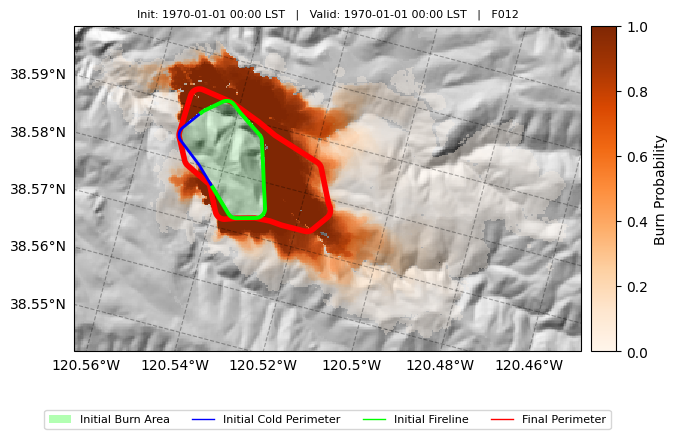

In [11]:
fid = "CA3858612053820210815"
nc_file = "sample_caldor_output.zip"
interval = "0.5"
fcube = "../../../"
output = "figure_plots"

postprocess_from_shell(fid, nc_file, interval, fcube, output)

Processing single interval: 1.5
Retrieved FireCube fields
Plotting burn probability


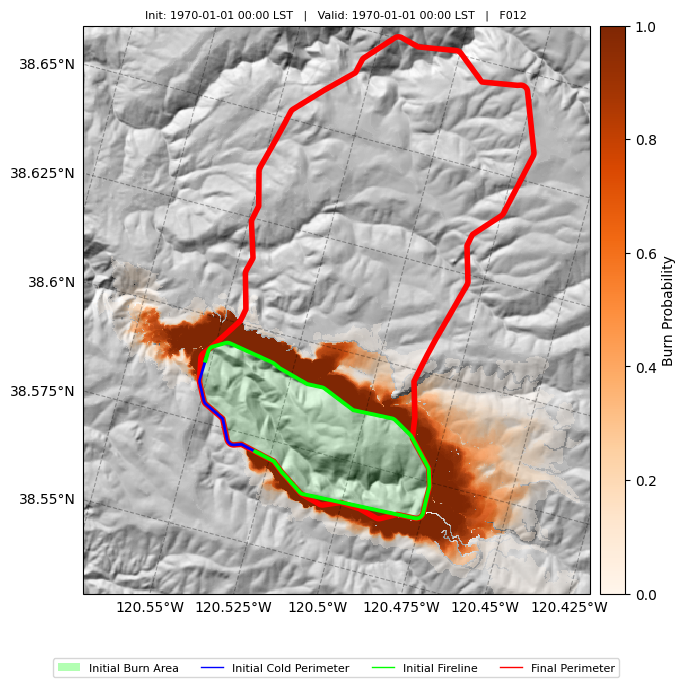

In [12]:
interval = "1.5"

postprocess_from_shell(fid, nc_file, interval, fcube, output)

In [4]:
''' Make fire progression plot for paper '''
def plot_fire_progression(fid, nc_file, firecube_path, output_path):
    args = [
        "--fire-id",
        fid,
        "--firecube-path",
        firecube_path,
        "--output-path",
        output_path,
        "--input",
        nc_file
    ]

    args = parse_args(args)

    ds = get_dataset(args)

    sup_title, proj, transform, extent, hillshade = get_firecube_data(args)

    #retrieve perimeters
    perimeters = shapely.from_wkt(ds["perimeter_initial"].values)
    src_crs = ds.attrs.get('crs', 'EPSG:5070')
    perimeters_reprojected = gpd.GeoDataFrame({'days' : ds.interval.values}, geometry=perimeters, crs=src_crs)

    #compute new burn regions
    fire_prog = []
    for i in range(len(perimeters_reprojected)):
        current_geom = perimeters_reprojected.geometry.iloc[i]
        
        if i == 0:
            fire_prog.append(current_geom)
        else:
            previous_geom = perimeters_reprojected.geometry.iloc[i-1]
            new_ba = current_geom.difference(previous_geom)
            fire_prog.append(new_ba)
    prog_gdf = perimeters_reprojected.copy()
    prog_gdf.geometry = fire_prog

    # MAKE FIRE PROGRESSION FIGURE
    print("Plotting fire progression")

    #set up figure
    fig_width = 7
    fig_height = (fig_width * ds.sizes['y'] / ds.sizes['x']) + 1
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height), subplot_kw={'projection': proj})

    #plot hillshade layer
    ax.imshow(hillshade, cmap='gray', extent=extent,
              origin='upper', transform=proj, alpha=1.0)
    
    #plot final observed fireline
    prog_gdf.plot(
        ax=ax,
        column='days',
        cmap='nipy_spectral',
        alpha=0.4,
        edgecolor=None,
    )
    perimeters_reprojected.plot(
        ax=ax,
        column='days', 
        cmap='nipy_spectral',
        facecolor="none",
        linewidth=1.5,
        alpha=1.0
    )

    #make colorbar and bottom legend
    d_min, d_max = ds.interval.min(), ds.interval.max()
    day_norm = colors.Normalize(vmin=d_min, vmax=d_max)
    day_cmap = plt.colormaps['nipy_spectral']
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.1, axes_class=maxes.Axes)
    cbar_mappable = cm.ScalarMappable(norm=day_norm, cmap=day_cmap)
    cbar_mappable.set_array(ds.interval.values)
    fig.colorbar(cbar_mappable, cax=cax, label="Days Since Ignition")

    '''
    #add titles
    fig.suptitle(
        "Burn Probability Field of " + sup_title,
        fontsize=10,
        fontweight='bold'
    )
    '''

    #add lat/lon grid
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), 
                  linestyle='--', color='black', alpha=0.3)
    gl.top_labels = False
    gl.right_labels = False

    #plt.tight_layout()
    fname = "burn_progression.png"
    output_file = os.path.join(args.output_path, fname)
    #plt.savefig(output_file, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

Plotting fire progression


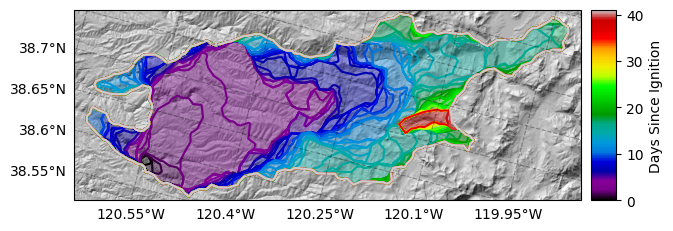

In [5]:
plot_fire_progression(fid, nc_file, fcube, output)